<a href="https://colab.research.google.com/github/kanish-27/KanishKrishna-Codeboosters-Internship-2026/blob/main/Phase_01_Data_Engineering/Day_04_BigData_PySpark_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv("/content/SOCR-HeightWeight.csv")

In [ ]:
df.head()

,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971


In [ ]:
x=df[['Height(Inches)']]

In [ ]:
y=df['Weight(Pounds)']

In [ ]:
df.isnull().any()

,0
Index,False
Height(Inches),False
Weight(Pounds),False


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model=LinearRegression()

In [ ]:
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_predict=model.predict(x_test)

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [ ]:
mean_absolute_error(y_test,y_predict)

8.107668347044479

In [ ]:
mean_squared_error(y_test,y_predict)

102.92310315418668

In [ ]:
r2_score(y_test,y_predict)

0.25423775123890735

In [ ]:
import joblib

In [ ]:
joblib.dump(model,"linear.pkl")

['linear.pkl']

In [ ]:
!pip install pyspark --quiet

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import year,month,to_date,col,round as spark_round
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
spark=SparkSession.builder \
.appName('Day4_BigData_Sales') \
.config('spark.sql.adaptive.enabled','true') \
.getOrCreate()
print(f'Spark version : {spark.version}')
print(f'SparkSesion : ACTIVE')
print(f'Application : {spark.sparkContext.appName}')

Spark version : 4.0.2
SparkSesion : ACTIVE
Application : Day4_BigData_Sales


In [ ]:
cd_bronze=spark.read \
.option('header','true') \
.option('inferSchema','true') \
.csv('/content/large_sales_data.csv')
print('=== BRONZE LAYER - RAW Data ===')
print(f'Rows : {cd_bronze.count()}')
print(f'Columns :{len(cd_bronze.columns)}')
print(f'Names : {cd_bronze.columns}')
print()
cd_bronze.printSchema()


=== BRONZE LAYER - RAW Data ===
Rows : 5000
Columns :13
Names : ['order_id', 'customer_name', 'product', 'category', 'quantity', 'unit_price', 'revenue', 'order_date', 'city', 'region', 'sales_rep', 'payment_method', 'order_status']

root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)



In [ ]:
print("First 5 rows:")
cd_bronze.show(5,truncate=False)
print('\nBasic statistics for numeric columns:')
cd_bronze.select('quantity','unit_price','revenue').describe().show()

First 5 rows:
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|order_id|customer_name|product   |category   |quantity|unit_price|revenue|order_date|city     |region|sales_rep  |payment_method  |order_status|
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|1001    |Sneha Reddy  |Monitor   |Electronics|12      |22000     |264000 |2023-05-21|Mumbai   |West  |Meera Patel|UPI             |Delivered   |
|1002    |Ramesh Kumar |Printer   |Electronics|10      |12000     |120000 |2023-08-05|Delhi    |North |Anil Sharma|Credit Card     |Shipped     |
|1003    |Rahul Mishra |Mouse     |Accessories|10      |800       |8000   |2023-01-14|Ahmedabad|West  |Meera Patel|Cash on Delivery|Shipped     |
|1004    |Suresh Rao   |Tablet    |Electronics|5       |32000     |160000 |2023-01-04|Surat    |West  |Ravi Ku

In [ ]:
cd_bronze.write \
.mode('overwrite') \
.parquet('sales_bronze.parquet')

In [ ]:
df_silver=cd_bronze \
.dropDuplicates() \
.dropna(subset=['order_id','product','revenue'])
df_silver=df_silver.withColumn(
    'order_date',
    to_date(col('order_date'),'yyyy-MM-dd')
)
df_silver=df_silver \
.withColumn('order_year',year(col('order_date'))) \
.withColumn('order_month',month(col('order_date')))
df_silver=df_silver.withColumn(
    'revenue_category',
    F.when(col('revenue')>40000,'High')
    .when(col('revenue')>10000,'Medium')
    .otherwise('Low')
)
print(f'Silver layer rows : {df_silver.count()}')
print(f'New Columns added: order_year,order_month,revenue_category')
df_silver.select('product','revenue','order_year','order_month','revenue_category').show(8)

Silver layer rows : 5000
New Columns added: order_year,order_month,revenue_category
+----------+-------+----------+-----------+----------------+
|   product|revenue|order_year|order_month|revenue_category|
+----------+-------+----------+-----------+----------------+
|  Keyboard|  13200|      2023|          2|          Medium|
|    Webcam|  17500|      2023|          1|          Medium|
|   Speaker|  58500|      2023|          4|            High|
|  Keyboard|   9600|      2023|         12|             Low|
|    Laptop| 180000|      2023|          8|            High|
|Headphones|  38500|      2023|          5|          Medium|
|    Webcam|  35000|      2023|         11|          Medium|
|    Laptop| 360000|      2023|          1|            High|
+----------+-------+----------+-----------+----------------+
only showing top 8 rows


In [ ]:
import os
def get_dir_size(path):
  if os.path.isfile(path):
    return os.path.getsize(path)/1024
  total=0
  for dirpath,dirnames,filenames in os.walk(path):
    for f in filenames:
      total += os.path.getsize(os.path.join(dirpath,f))
  return total/1024
  csv_size=get_dir_size('large_sales_data.csv')
  parquet_size=get_dir_size('sales_bronze.parquet')

In [ ]:
df_silver.write \
.mode('overwrite') \
.parquet('Sales_silver.parquet')
print('Silver Parquet saved: Sales_silver.parquet')
print(f'Silver size:{get_dir_size("Sales_silver.parquet"):.1F}KB')
df_verify=spark.read.parquet('Sales_silver.parquet')
print(f'Read-back rows : {df_verify.count()}(should match Silver count)')
df_verify.printSchema()

Silver Parquet saved: Sales_silver.parquet
Silver size:59.8KB
Read-back rows : 5000(should match Silver count)
root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_year: integer (nullable = true)
 |-- order_month: integer (nullable = true)
 |-- revenue_category: string (nullable = true)



In [ ]:
top_products=df_silver \
.groupBy('product') \
.agg(
    F.sum('revenue').alias('total_revenue'),
    F.count('order_id').alias('num_orders'),
    F.avg('revenue').alias('avg_order_revenue')
) \
.orderBy('total_revenue',ascending=False) \
.limit(5)

print('=== Top 5 Products by Revenue ===')
top_products.show(truncate=False)

=== Top 5 Products by Revenue ===
+-------+-------------+----------+------------------+
|product|total_revenue|num_orders|avg_order_revenue |
+-------+-------------+----------+------------------+
|Laptop |182700000    |502       |363944.22310756973|
|Tablet |135104000    |532       |253954.8872180451 |
|Monitor|82126000     |481       |170740.12474012474|
|Printer|44544000     |488       |91278.68852459016 |
|Speaker|16317000     |470       |34717.02127659575 |
+-------+-------------+----------+------------------+



In [ ]:
gold_products=df_silver \
.groupBy('product','category') \
.agg(
    F.sum('revenue').alias('total_revenue'),
    F.count('order_id').alias('units_sold'),
    spark_round(F.avg('quantity'),1).alias('avg_quantity_per_order'),
    F.max('revenue').alias('largest_order')
) \
.orderBy('total_revenue',ascending=False)
gold_products.write.mode('overwrite').parquet('gold_product_summary.parquet')

In [ ]:
monthly_trend=df_silver \
.groupBy('order_month') \
.agg(
    F.sum('revenue').alias('monthly_revenue'),
    F.count('order_id').alias('monthly_orders')) \
    .orderBy('order_month')
monthly_trend.write.mode('overwrite').parquet('gold_monthly_trend.parquet')
print('=== Monthly Revenue Trend ===')
monthly_trend.show(12)

=== Monthly Revenue Trend ===
+-----------+---------------+--------------+
|order_month|monthly_revenue|monthly_orders|
+-----------+---------------+--------------+
|          1|       41068200|           423|
|          2|       34485400|           375|
|          3|       40031200|           451|
|          4|       38857100|           390|
|          5|       39984500|           423|
|          6|       40707400|           390|
|          7|       42640700|           405|
|          8|       43718500|           418|
|          9|       37640200|           398|
|         10|       47839000|           479|
|         11|       44577100|           419|
|         12|       44298300|           429|
+-----------+---------------+--------------+



In [ ]:
region_pd=spark.read.parquet('gold_region_revenue.parquet').toPandas()
product_pd = spark.read.parquet('gold_product_summary.parquet').toPandas()
monthly_pd = spark.read.parquet('gold_monthly_trend.parquet').toPandas()
print('Gold tables converted to Pandas: ')
print(f'  Region  : {region_pd.shape}')
print(f'  Product : {product_pd.shape}')
print(f'  Monthly : {monthly_pd.shape}')

Gold tables converted to Pandas: 
  Region  : (4, 2)
  Product : (10, 6)
  Monthly : (12, 3)


In [ ]:
gold_region = df_silver \
    .groupBy('region') \
    .agg(F.sum('revenue').alias('total_revenue')) \
    .orderBy('total_revenue', ascending=False)
gold_region.write.mode('overwrite').parquet('gold_region_revenue.parquet')

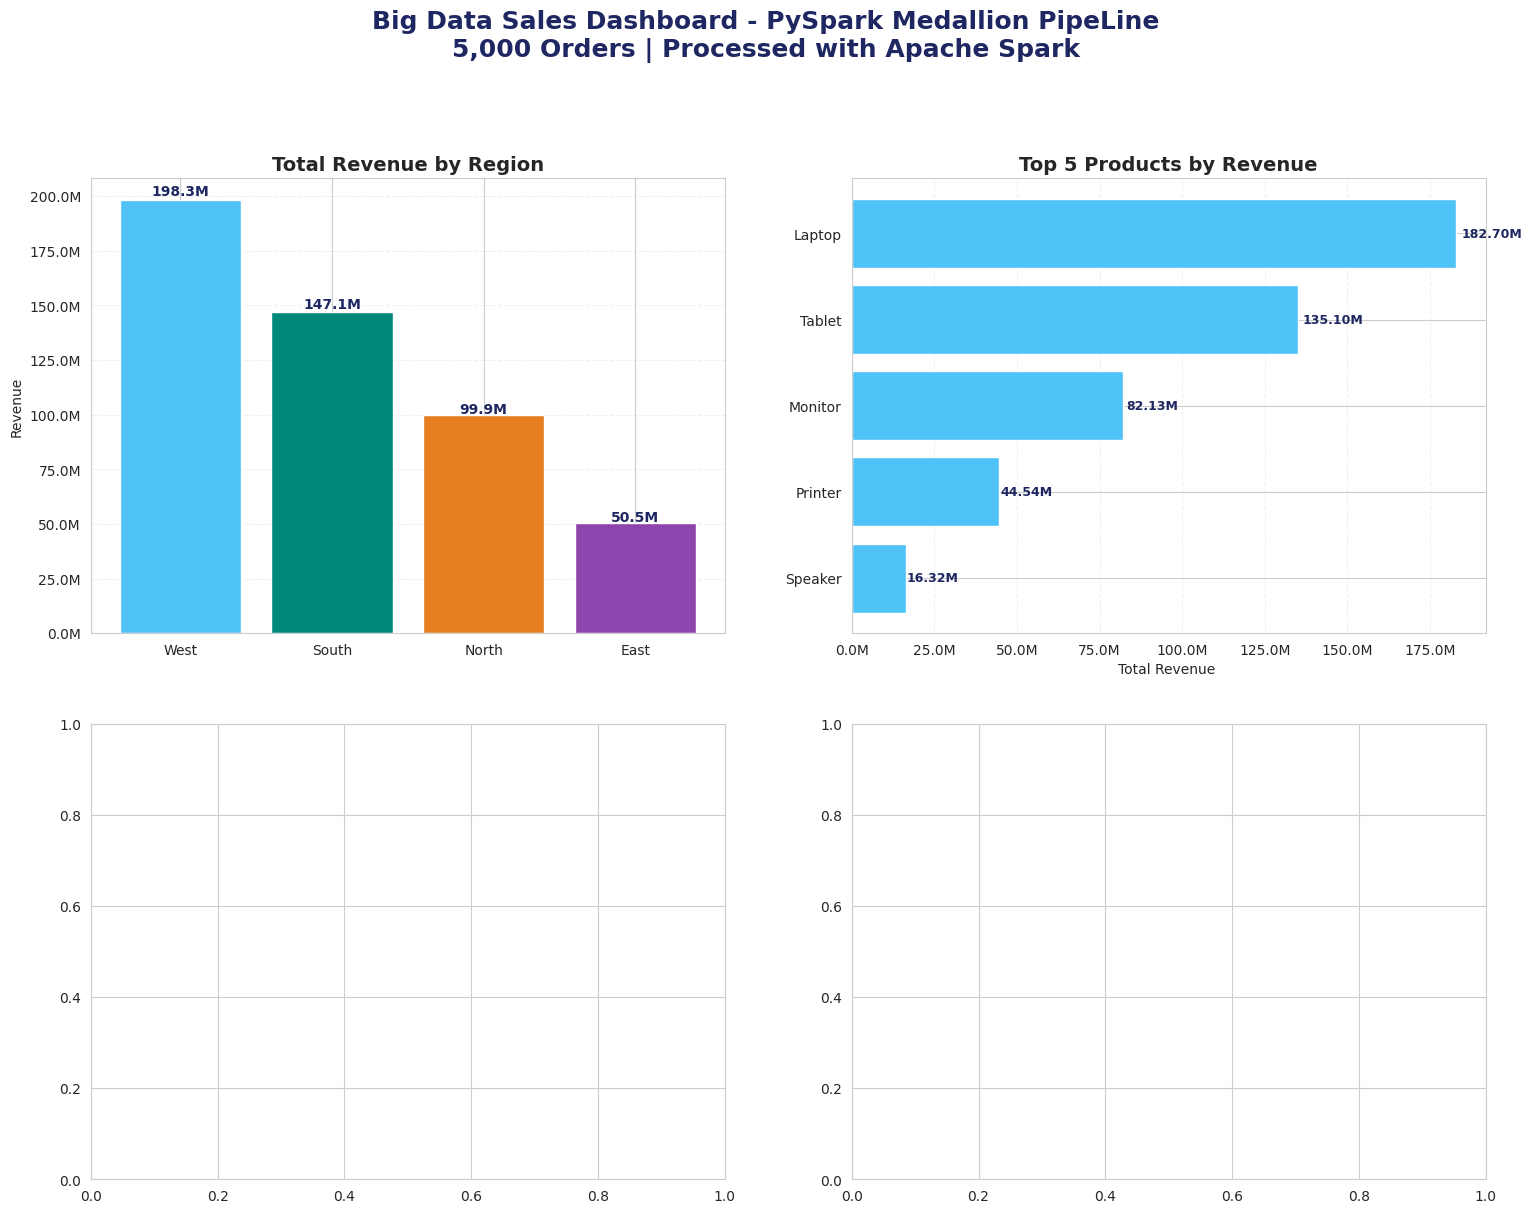

In [ ]:
import matplotlib.pyplot as plt
fig,axes=plt.subplots(2,2,figsize=(18,13))
fig.suptitle(
    'Big Data Sales Dashboard - PySpark Medallion PipeLine\n'
    '5,000 Orders | Processed with Apache Spark',
    fontsize=18,fontweight='bold',color='#1E2761',y=1.01
)
color4=['#4FC3F7','#00897B','#E67E22','#8E44AD','#E74C3C']
ax1=axes[0][0]
bars1=ax1.bar(region_pd['region'],region_pd['total_revenue'],color=color4[:len(region_pd)],edgecolor='white')
for bar in bars1:
  ax1.text(bar.get_x()+bar.get_width()/2,bar.get_height()*1.01,f'{bar.get_height()/1e6:.1F}M',ha='center',fontsize=10,fontweight='bold',color='#1E2761')
ax1.set_title('Total Revenue by Region',fontsize=14,fontweight='bold')
ax1.set_ylabel('Revenue')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f'{x/1e6:.1F}M'))
ax1.grid(axis='y',alpha=0.3,linestyle='--')
ax2=axes[0][1]
top5_prod=product_pd.head(5).sort_values('total_revenue')
bars2=ax2.barh(top5_prod['product'],top5_prod['total_revenue'],color='#4FC3F7',edgecolor='white')
for bar in bars2:
  ax2.text(bar.get_width()*1.01,bar.get_y()+bar.get_height()/2,f'{bar.get_width()/1e6:.2F}M',va='center',fontsize=9,fontweight='bold',color='#1E2761')
ax2.set_title('Top 5 Products by Revenue',fontsize=14,fontweight='bold')
ax2.set_xlabel('Total Revenue ')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f'{x/1e6:.1F}M'))
ax2.grid(axis='x',alpha=0.3,linestyle='--')


In [ ]:
print('=== Activity 2: File Format Comparision ===')
print()

csv_kb=get_dir_size('large_sales_data.csv')
bronze_kb=get_dir_size('sales_bronze.parquet')
silver_kb=get_dir_size('Sales_silver.parquet')
gold_kb=get_dir_size(('gold_product_summary.parquet')+('gold_monthly_trend.parquet')+('gold_region_revenue.parquet'))
print(f"{'File':<38}{'Size (KB)':>10}{'vs CSV':>10}")

=== Activity 2: File Format Comparision ===

File                                   Size (KB)    vs CSV
